In [336]:
#For reading data visualisation
import numpy as np
import pandas as pd
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import seaborn as sns

#Preprocessing of Data
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder, StandardScaler

#Models for Predictions 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

#Model Evaluation
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, RocCurveDisplay, ConfusionMatrixDisplay
from scipy import stats
from sklearn.base import clone 
%matplotlib inline



In [337]:
from pathlib import Path

DATA_PATH = Path.cwd() / "data" / "ecommerce_dataset.xlsx"
print(DATA_PATH.exists()) 
df = pd.read_excel(DATA_PATH, sheet_name="E Comm")

True


In [338]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [339]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,5630.0,52815.500000,1625.385339,50001.0,51408.25,52815.50,54222.7500,55630.00
Churn,5630.0,0.168384,0.374240,0.0,0.00,0.00,0.0000,1.00
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.00,16.0000,61.00
CityTier,5630.0,1.654707,0.915389,1.0,1.00,1.00,3.0000,3.00
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
SatisfactionScore,5630.0,3.066785,1.380194,1.0,2.00,3.00,4.0000,5.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
Complain,5630.0,0.284902,0.451408,0.0,0.00,0.00,1.0000,1.00


In [340]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

### Data Cleaning

#### checking for missing value

In [341]:
#checking for missing value

missing_percent = (df.isnull().sum()[df.isnull().sum() > 0]/len(df))*100
print(missing_percent)

Tenure                         4.689165
WarehouseToHome                4.458259
HourSpendOnApp                 4.529307
OrderAmountHikeFromlastYear    4.706927
CouponUsed                     4.547069
OrderCount                     4.582593
DaySinceLastOrder              5.452931
dtype: float64


Since all missing rates are relatively low (<6%), we can apply imputation instead of removing rows or columns.

1️⃣ Numerical Columns

Columns like Tenure, HourSpendOnApp, OrderAmountHikeFromlastYear, OrderCount, DaySinceLastOrder are numeric.

Imputation method: Median imputation

Reason:  
a.Median is robust to outliers, unlike mean, which can be skewed by extreme values.  
b.Preserves the central tendency of the data.

In [342]:
numeric_cols = ['Tenure', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'OrderCount', 'DaySinceLastOrder']
for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)


2️⃣ Categorical Columns

Columns like CouponUsed and WarehouseToHome are categorical.

Imputation method: Mode (most frequent value) imputation

Reason:  
a.Categorical variables cannot be averaged.  
b.Mode preserves the original distribution and introduces minimal bias.

In [343]:
categorical_cols = ['CouponUsed', 'WarehouseToHome']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [344]:
# Done. Checking the missing values for the last time
df.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [345]:
df_1 = df.copy()

### Data Exploration and Visualization

#### The Percentage of Customer Churn

In [346]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [347]:
labels = ['Retained','Churn']
counts = df['Churn'].value_counts()
print(counts)

Churn
0    4682
1     948
Name: count, dtype: int64


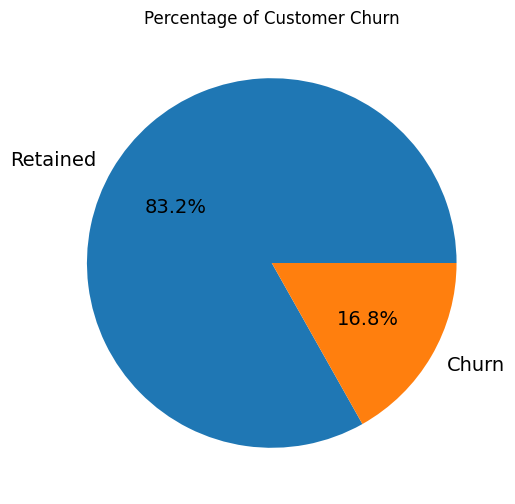

In [348]:
plt.figure(figsize=(6,6))
plt.title("Percentage of Customer Churn")
plt.pie(counts, autopct='%1.1f%%', labels=labels, textprops={"fontsize":14})
plt.show()

#### Customer Churn based on Gender

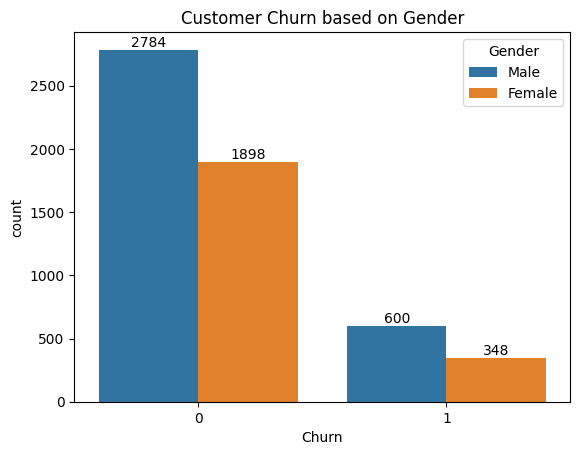

In [349]:
#which gender most likely to churn?

ax = sns.countplot(x=df['Churn'], hue=df['Gender'])
plt.title('Customer Churn based on Gender')

for container in ax.containers:
    ax.bar_label(container)
plt.show()

Male customer tends to churn than female, but also likely to retained.

#### Distribution of Order Count of Customers

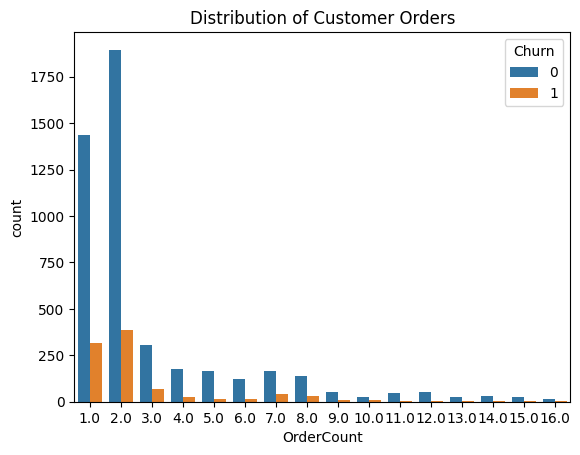

In [350]:
sns.countplot(x=df['OrderCount'], hue=df['Churn'])
plt.title("Distribution of Customer Orders")
plt.show()

Most customers only ordered 1-2 times.

#### Customer Preferred Login Device

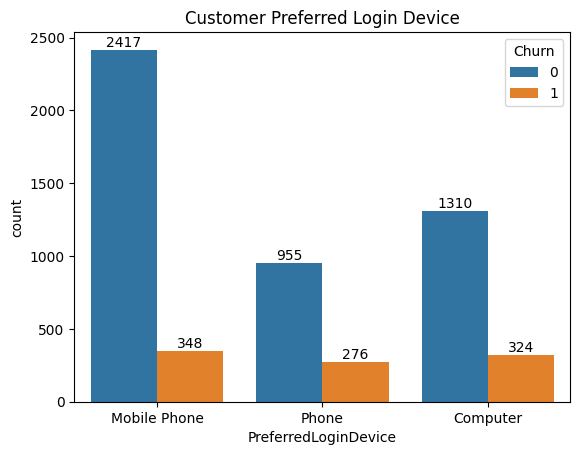

In [351]:
ax = sns.countplot(x=df['PreferredLoginDevice'], hue=df['Churn'])
plt.title('Customer Preferred Login Device')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

Churn: The number of mobile phone, phone, and computer is likely close with average 316 customer

#### Customer Preferred Payment

/var/folders/g0/kpb29ky50790twcth2kc16r40000gn/T/ipykernel_20495/3905540632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['PreferredPaymentMode'], palette='Set2')


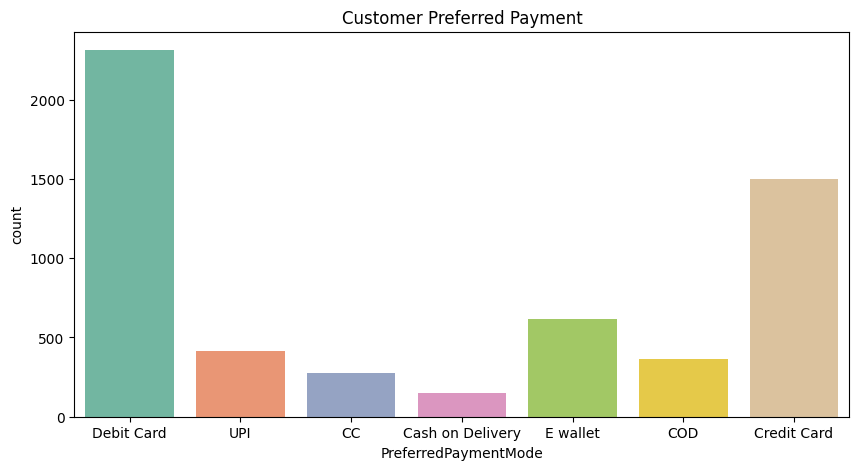

In [352]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['PreferredPaymentMode'], palette='Set2')
plt.title('Customer Preferred Payment')
plt.show()

Customers prefer to make payments with debit and credit cards.

#### Customer Preferred Order Category

/var/folders/g0/kpb29ky50790twcth2kc16r40000gn/T/ipykernel_20495/1647919779.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['PreferedOrderCat'],palette='Set2')


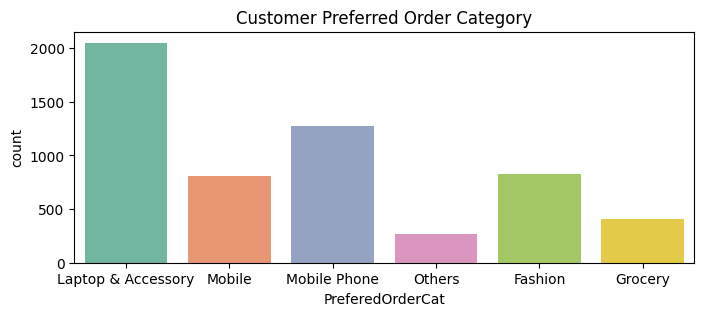

In [353]:
plt.figure(figsize=(8,3))
sns.countplot(x=df['PreferedOrderCat'],palette='Set2')
plt.title('Customer Preferred Order Category')
plt.show()

In this E-commerce, customers order category for Laptop & Accessory is higher than other categories.

#### Customer Distance from Warehouse to Home

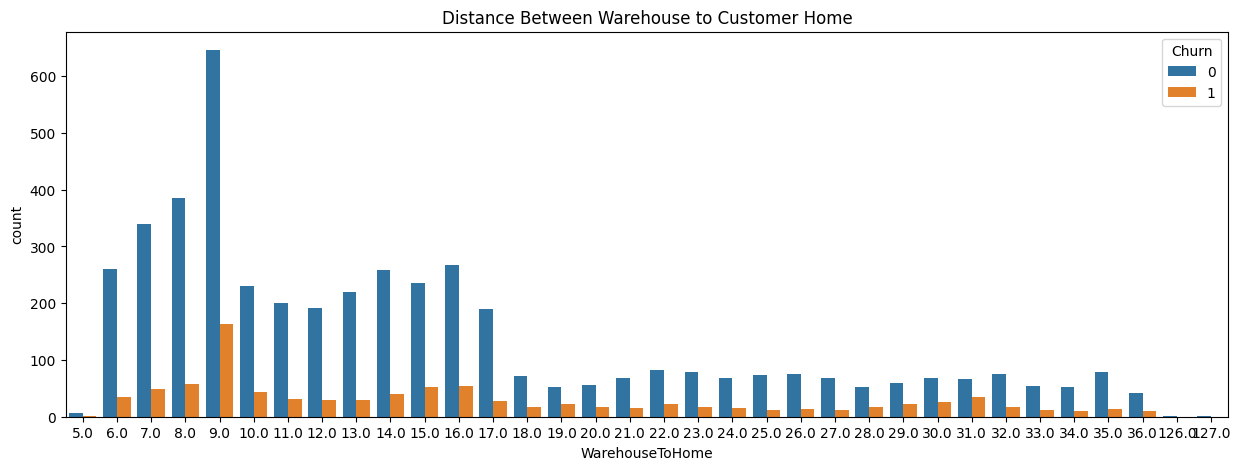

In [354]:
plt.figure(figsize=(15,5))
sns.countplot(x=df['WarehouseToHome'], hue=df['Churn'])
plt.title('Distance Between Warehouse to Customer Home')
plt.show()

This figure shows there is no correlation between warehouse to home distance with customer churn. But we'll confirm this with correlation matrix.

#### Customer City Tier

/var/folders/g0/kpb29ky50790twcth2kc16r40000gn/T/ipykernel_20495/544636072.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['CityTier'],palette='Set1')


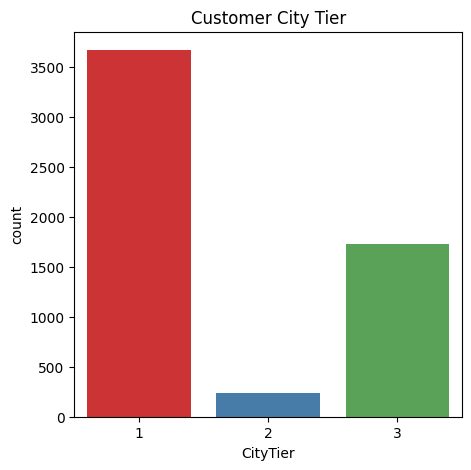

In [355]:
plt.figure(figsize=(5,5))
sns.countplot(x=df['CityTier'],palette='Set1')
plt.title('Customer City Tier')
plt.show()

City Tier 2, has low number customer

#### Customer Hour Spend On App

/var/folders/g0/kpb29ky50790twcth2kc16r40000gn/T/ipykernel_20495/2296409582.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['HourSpendOnApp'], palette='Set1')


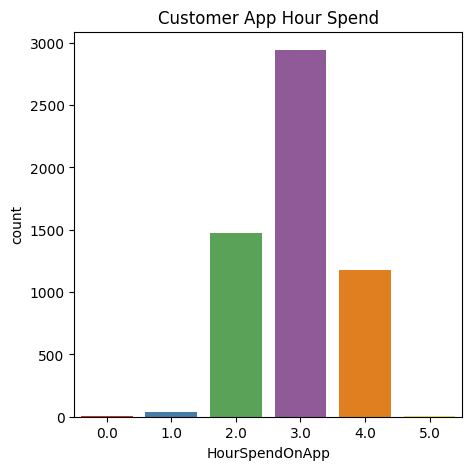

In [356]:
plt.figure(figsize=(5,5))
sns.countplot(x=df['HourSpendOnApp'], palette='Set1')
plt.title('Customer App Hour Spend')
plt.show()

People like to spend 2-4 hours on this E-commerce app

#### Customers Satisfaction Score

Average Satisfaction Score: 3.066785079928952


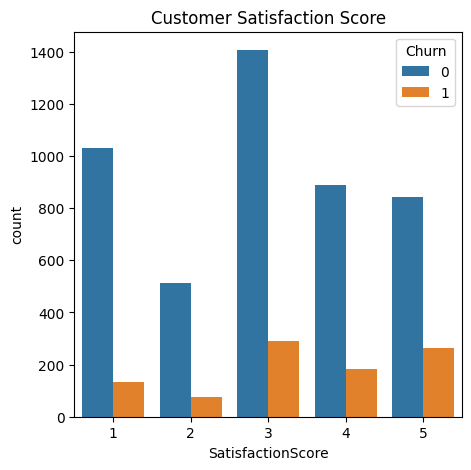

In [357]:
average_score = df['SatisfactionScore'].mean()
print('Average Satisfaction Score:',average_score)

plt.figure(figsize=(5,5))
sns.countplot(x=df['SatisfactionScore'], hue=df['Churn'])
plt.title('Customer Satisfaction Score')
plt.show()

From scale 1-5 the average satisfaction score is 3.06. Customers satisfaction are neutral.


#### Customer Marital Status

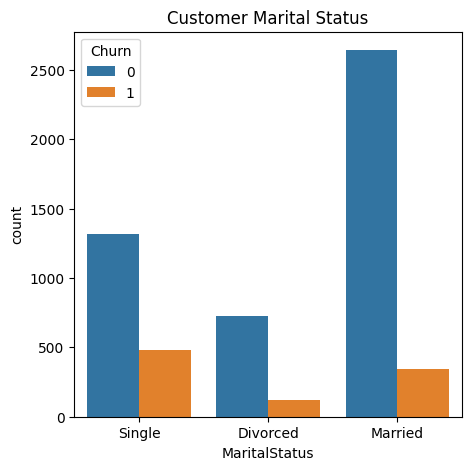

In [358]:
plt.figure(figsize=(5,5))
sns.countplot(x=df['MaritalStatus'], hue=df['Churn'])
plt.title('Customer Marital Status')
plt.show()

#### Customer Complains

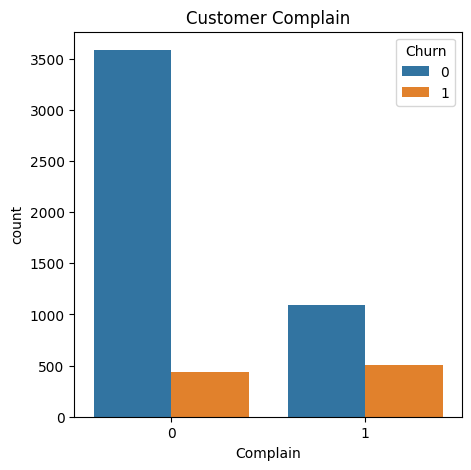

In [359]:
plt.figure(figsize=(5,5))
sns.countplot(x=df['Complain'], hue=df['Churn'])
plt.title('Customer Complain')
plt.show()

Customers who churn more likely complain in their last month


#### Customer Order

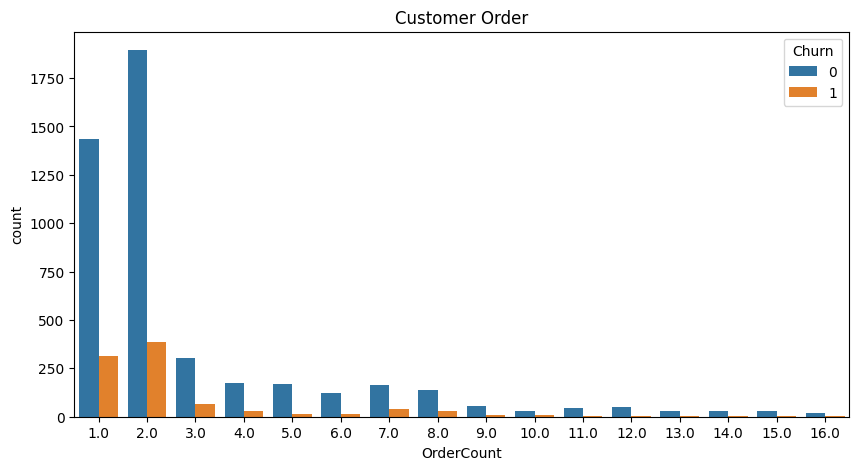

In [360]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['OrderCount'], hue=df['Churn'])
plt.title('Customer Order')
plt.show()

From figure above notice that high number in their 1st and 2nd order, this means customer churn after their first or second order


#### Customer Used Coupon

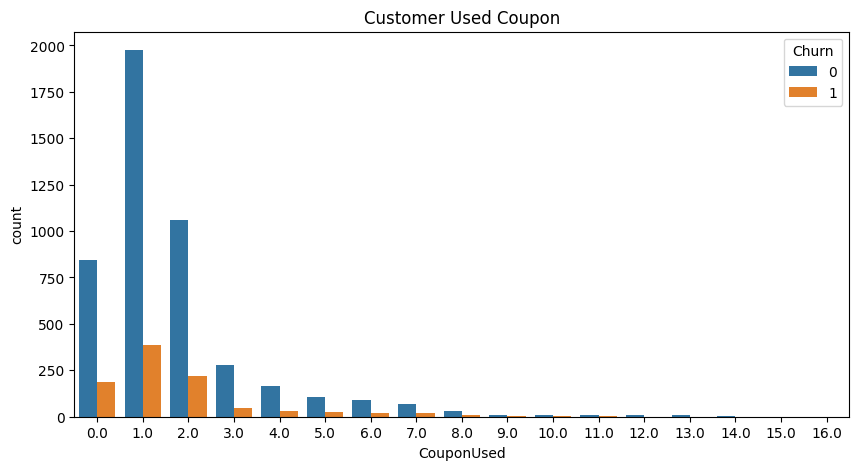

In [361]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['CouponUsed'], hue=df['Churn'])
plt.title('Customer Used Coupon')
plt.show()

#### Customer Day Since Last Order

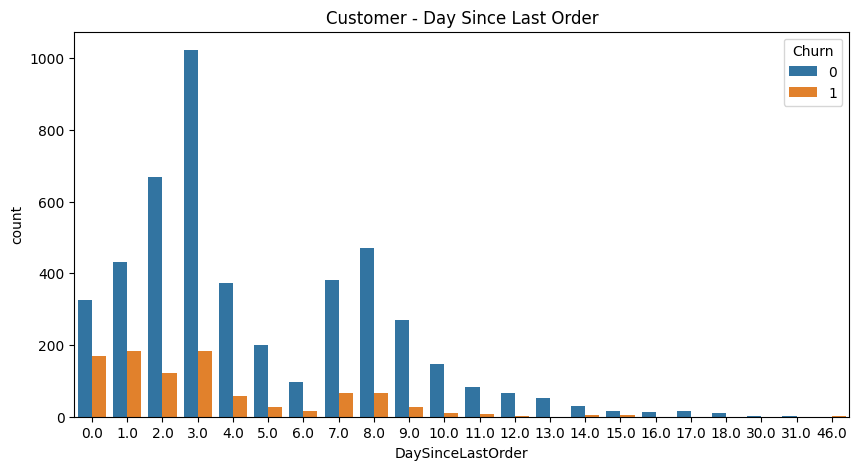

In [362]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['DaySinceLastOrder'], hue=df['Churn'])
plt.title('Customer - Day Since Last Order')
plt.show()

We notice customers leave e-commerce after a week since their last order

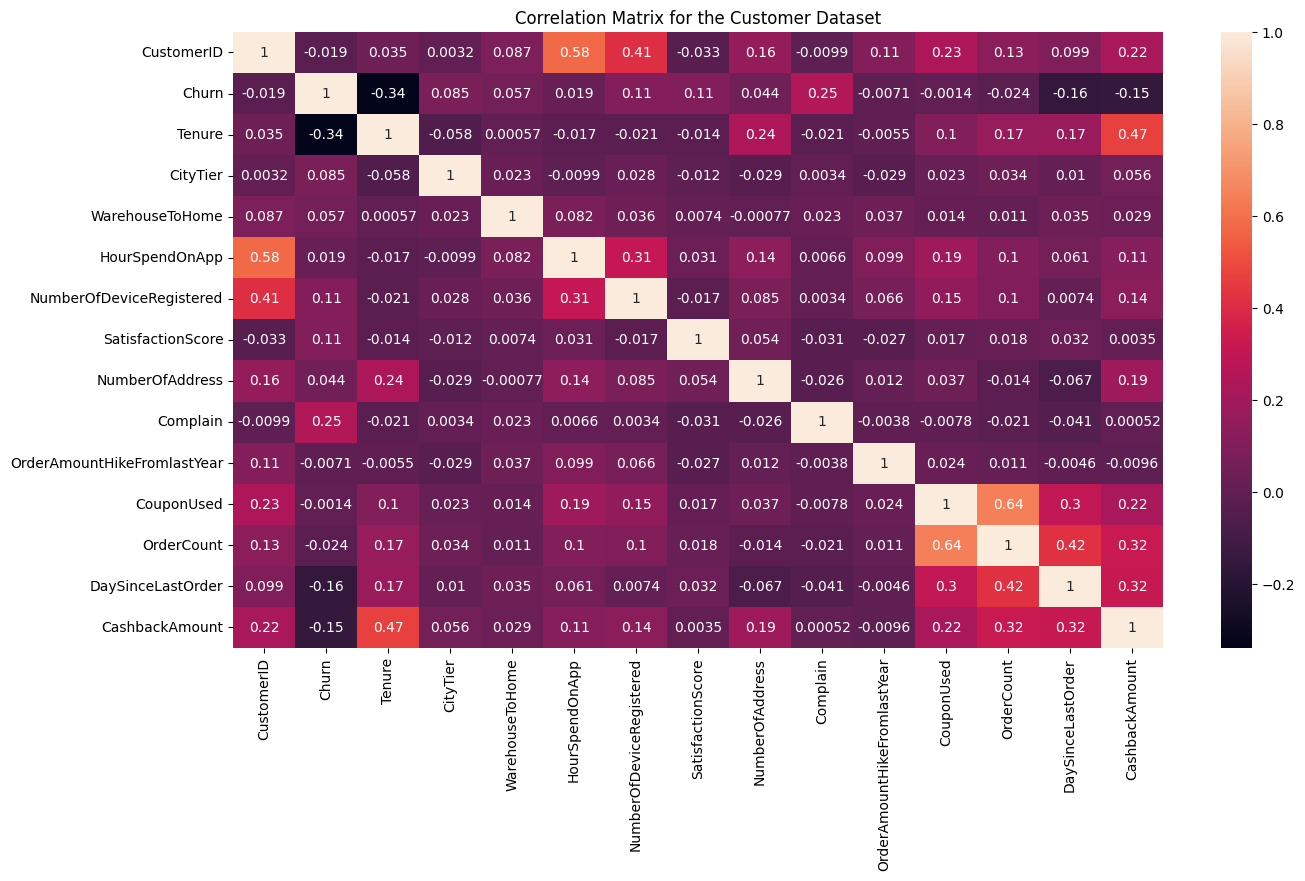

In [363]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix for the Customer Dataset")
plt.show()

##### Findings from analysis:
1. There are 4682 users (82.2%) retained, while 948 users (16.8%) has churned.
2. Customers spend 2-4 hours in the app.
3. Customers mostly only order 1-2 times.
4. Warehouse to home distance doesn't affect customer churn.
5. Customers who complain and also with single status have higher churn rate
6. From correlation matrix, correlation between WarehouseToHome and Churn is 0.07 (0.069544 to be more precise). This means weak or no correlation.

#### Metrics evaluating why customers leave and how to improve retention.

In [364]:
# 1. Impact of Complaints on Churn Rate
complain_churn = pd.crosstab(df_1['Complain'], df_1['Churn'], normalize='index') 
print("Churn Rate based on Complaints (%):\n", complain_churn)

Churn Rate based on Complaints (%):
 Churn            0         1
Complain                    
0         0.890710  0.109290
1         0.683292  0.316708


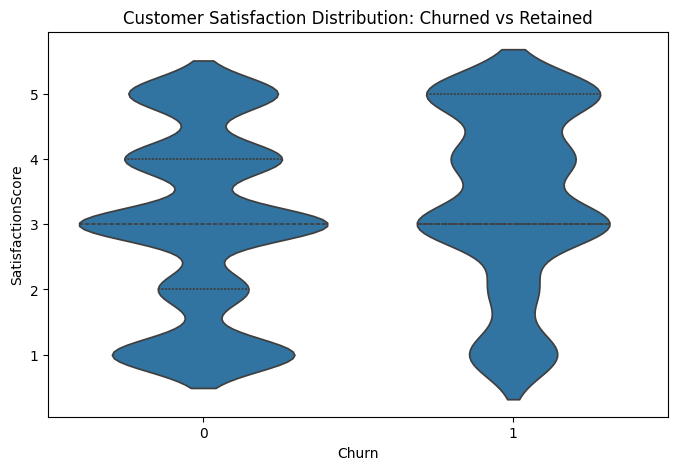

In [365]:
# 2. Satisfaction Score vs Churn
plt.figure(figsize=(8, 5))
sns.violinplot(x='Churn', y='SatisfactionScore', data=df_1, inner="quart")
plt.title('Customer Satisfaction Distribution: Churned vs Retained')
plt.show()

Business Insight: the churn rate for complaining customer is 3 times higher than non-complaint customer. It indicates that the customer support is failing, and causing serious customer churn

#### the relationship between Warehouse distance and Churn

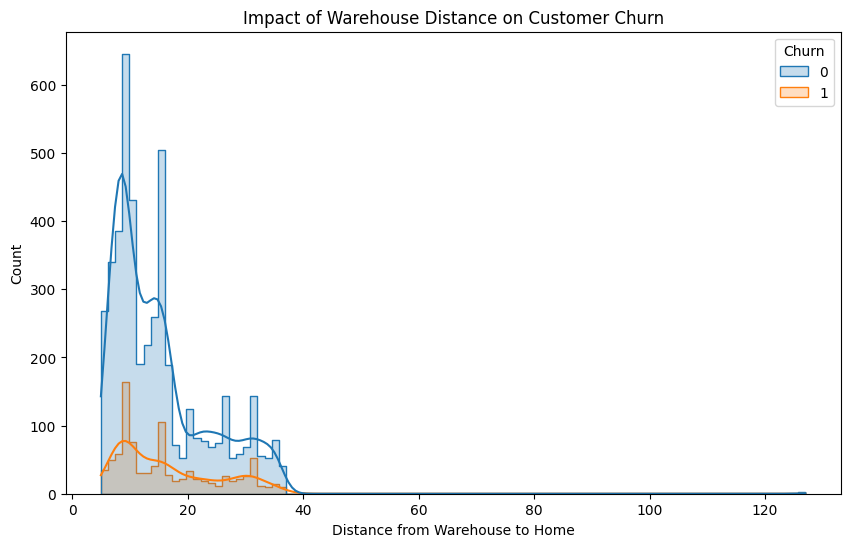

In [366]:
# Analyzing the relationship between Warehouse distance and Churn
plt.figure(figsize=(10, 6))
sns.histplot(data=df_1, x='WarehouseToHome', hue='Churn', kde=True, element="step")
plt.title('Impact of Warehouse Distance on Customer Churn')
plt.xlabel('Distance from Warehouse to Home')
plt.show()

Business Insight: churn spikes when the distance between 20 km--33 km 

#### Customer Loyalty & Lifecycle Analysis

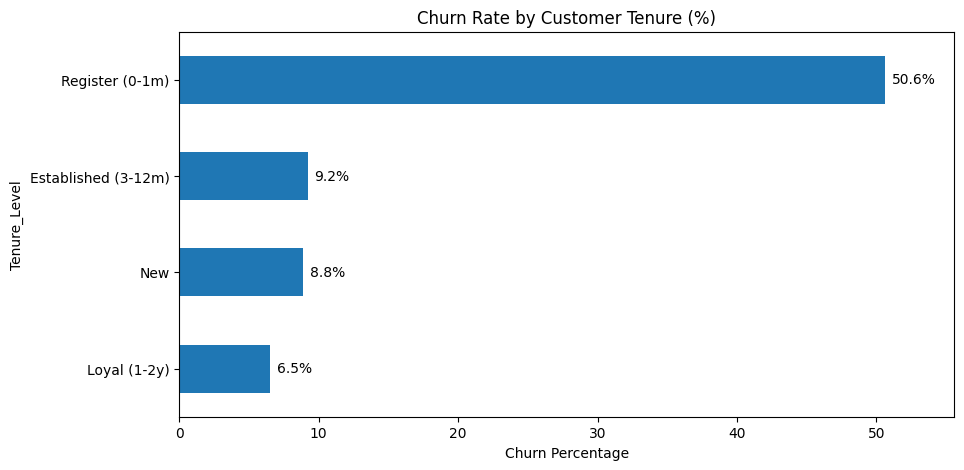

In [393]:
# Create Tenure Groups
df_1['Tenure_Level'] = pd.cut(df_1['Tenure'], bins=[0, 1, 3, 12, 24], 
                            labels=['Register (0-1m)','New', 'Established (3-12m)', 'Loyal (1-2y)'])

# Calculate Churn Rate per Tenure Group
tenure_analysis = df_1.groupby('Tenure_Level')['Churn'].mean().sort_values() * 100

plt.figure(figsize=(10, 5))
ax = tenure_analysis.plot(kind='barh')

plt.title('Churn Rate by Customer Tenure (%)')
plt.xlabel('Churn Percentage')
plt.xlim(0, tenure_analysis.max() + 5)

for i, value in enumerate(tenure_analysis):
    ax.text(value + 0.5, i, f'{value:.1f}%', va='center')

plt.show()

New customer have the highest churn. The "loyal" customer also start churning, it means competitors is poaching them, and the loyalty program is outdated.

#### Marketing Efficiency: Cashback & Coupon ROI

In [368]:
# create bins for cashback(low,medium,high)
df_1['Cashback_Level'] = pd.qcut(df_1['CashbackAmount'],q=3, labels=['low cashback','medium cashback','high cashback'])

# define the metrics
roi_table = df_1.groupby('Cashback_Level').agg(
    Avg_Cashback=('CashbackAmount', 'mean'),
    Avg_Coupons_Used=('CouponUsed', 'mean'),
    Churn_Rate=('Churn', 'mean'),
    Avg_Order_Hike=('OrderAmountHikeFromlastYear', 'mean'),
    Avg_Order_Count=('OrderCount', 'mean')
).reset_index()

# calculate an efficiency ratio(order hike per dollar of cashback)
roi_table['Efficiency_Ratio'] = roi_table['Avg_Order_Hike'] / roi_table['Avg_Cashback']

# format percentages for readability
roi_table['Churn_Rate'] = (roi_table['Churn_Rate'] * 100).round(2).astype(str) + '%'
roi_table = roi_table.round(2)

print(roi_table)

    Cashback_Level  Avg_Cashback  Avg_Coupons_Used Churn_Rate  Avg_Order_Hike  \
0     low cashback        134.56              1.16     25.53%           15.58   
1  medium cashback        163.60              1.76     13.77%           15.77   
2    high cashback        233.58              2.24     11.19%           15.67   

   Avg_Order_Count  Efficiency_Ratio  
0             2.00              0.12  
1             2.85              0.10  
2             4.05              0.07  


##### Insights
1. Diminishing Returns (The "Satiation" Point)    
the efficiency ratio drops significantly from "low" to "high"(0.12-->0.07), it means the merchant spend a lot more money for very small marginal gains in order to growth.

2. Coupon Addiction vs. True Loyalty  
'high cashback' group has a high coupon count but the churn rate is still relatively high(11.19%),these customers are "Deal Seekers." They are only loyal to the discount, not the platform.

3. Churn Suppression Effectiveness   
The churn rate drops by 11.34% despite a $100 increase in avg cashback. It means the marketing spend is effective at retaining customers 

4. Growth Driver   
High cashback correlates with a high order amount hike, the cashback program is successfully encouraging customers to spend more thank they did last year.

### Feature Engineering

#### Trend Feature

In [369]:
# new feature creation

def create_business_features(df):
    #avoid division by zero by adding a small constant
    df['Tenure'] = df['Tenure'].replace(0,0.1)

    # Feature 1: Order Frequency (Orders per month of tenure)
    df['Order Frequency'] = df['OrderCount']/ df['Tenure']

    # Feature 2: Incentive Efficiency (Cashback per order)
    df['Cashback_per_Order'] = df['CashbackAmount'] / (df['OrderCount'] + 1)
    
    # Feature 3: Complaint Impact Score (Low satisfaction + Complaint = High Risk)
    # Satisfaction is 1-5, so (6-Satisfaction) makes 5 the worst.
    df['Complain_Score'] = df['Complain'] * (6 - df['SatisfactionScore'])
    
    # Feature 4: Address Density (Frequent movers or complex shipping)
    df['Address_per_Tenure'] = df['NumberOfAddress'] / df['Tenure']
    
    return df

#apply feature creation
df = create_business_features(df)

### Data Preprocessing

1. Convert categorical features to numeric using Label Encoding
2. Define feature matrix X and target variable y (Churn)

In [370]:
cols_to_drop = [
    'SatisfactionScore', 
    'Complain', 
    'CashbackAmount', 
    'OrderCount'
]

df_cleaned = df.drop (columns=cols_to_drop)

print("Remaining features for modeling:", df_cleaned.columns.tolist())

Remaining features for modeling: ['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'MaritalStatus', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'DaySinceLastOrder', 'Order Frequency', 'Cashback_per_Order', 'Complain_Score', 'Address_per_Tenure']


In [371]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols)

Categorical Columns: Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')


In [372]:
#transfer categorical_col to numerical col using one-hot coding
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[categorical_cols])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(categorical_cols))

df_encoded = pd.concat([df, one_hot_df], axis=1)

df_encoded = df_encoded.drop(categorical_cols, axis=1)


In [373]:
#split dataset
X = df_encoded.drop(['Churn','CustomerID'], axis=1)
y = df_encoded['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [374]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Model Trained & Compared

In [375]:
#define model
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42)
}

#store the result
results = []

for name, model in models.items():
    # train
    model.fit(X_train_scaled, y_train)
    
    # test
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    
    # calculate metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test,y_prob)
    })

# show as dataframe
df_results = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)


In [376]:
df_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.977798,0.987805,0.875676,0.928367,0.986386
1,Decision Tree,0.965364,0.888298,0.902703,0.895442,0.940193
2,SVM,0.923623,0.877863,0.621622,0.727848,0.945889
3,Logistic Regression,0.911190,0.829457,0.578378,0.681529,0.900508


Random Forest (Optimal Balance):   

It boasts the highest Precision (0.987),the highest ROC-AUC(0.986)  This is highly beneficial for companies implementing costly retention programs (such as human customer service calls) as resources are almost never wasted.

Decision Tree (Highest Recall): 

Its Recall (0.902) is even slightly higher than Random Forest. This indicates that Decision Tree can capture the largest number of potential churners.

#### Feature Importance


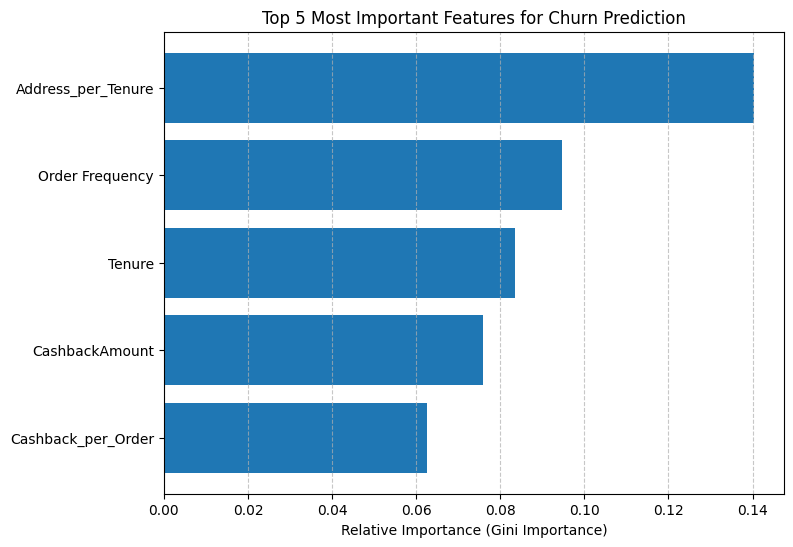

,Feature,Importance
16,Address_per_Tenure,0.140420
13,Order Frequency,0.094655
0,Tenure,0.083560
12,CashbackAmount,0.075832
14,Cashback_per_Order,0.062559


In [391]:
feature_names = X_train.columns

rf_model = models["Random Forest"]

#order the feature desc
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)



#Top 5
top_n = 5
top_features = feature_importance_df.head(top_n)

# indices
indices = np.arange(top_n)

# visualize
plt.figure(figsize=(8, 6))
plt.title('Top 5 Most Important Features for Churn Prediction')
plt.barh(indices, top_features['Importance'], align='center')
plt.yticks(indices, top_features['Feature'])
plt.xlabel('Relative Importance (Gini Importance)')
plt.gca().invert_yaxis()   # 最重要的在最上面
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

feature_importance_df.head(5)

In [378]:
df_encoded['churn_probability'] = rf_model.predict_proba(X)[:, 1]

df_encoded

/Users/kathyshi/Desktop/customer_churn_analysis /venv/lib/python3.8/site-packages/sklearn/base.py:458: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferedOrderCat_Fashion,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,churn_probability
0,50001,1,4.0,3,6.0,3.0,3,2,9,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.68
1,50002,1,9.0,1,8.0,3.0,4,3,7,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.66
2,50003,1,9.0,1,30.0,2.0,4,3,6,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.67
3,50004,1,0.1,3,15.0,2.0,4,5,8,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.55
4,50005,1,0.1,1,12.0,3.0,3,5,3,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10.0,1,30.0,3.0,2,1,6,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.56
5626,55627,0,13.0,1,13.0,3.0,5,5,6,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.52
5627,55628,0,1.0,1,11.0,3.0,2,4,3,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.64
5628,55629,0,23.0,3,9.0,4.0,5,4,4,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.55


In [379]:
def risk_bucket(p):
    if p >= 0.7:
        return 'High'
    elif p >= 0.4:
        return 'Medium'
    else:
        return 'Low'

df_encoded['risk_bucket'] = df_encoded['churn_probability'].apply(risk_bucket)


In [380]:
df_encoded.head(10)

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,churn_probability,risk_bucket
0,50001,1,4.0,3,6.0,3.0,3,2,9,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.68,Medium
1,50002,1,9.0,1,8.0,3.0,4,3,7,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.66,Medium
2,50003,1,9.0,1,30.0,2.0,4,3,6,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.67,Medium
3,50004,1,0.1,3,15.0,2.0,4,5,8,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.55,Medium
4,50005,1,0.1,1,12.0,3.0,3,5,3,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.60,Medium
5,50006,1,0.1,1,22.0,3.0,5,5,2,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.70,High
6,50007,1,9.0,3,11.0,2.0,3,2,4,0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.50,Medium
7,50008,1,9.0,1,6.0,3.0,3,2,3,1,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.61,Medium
8,50009,1,13.0,3,9.0,3.0,4,3,2,1,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.60,Medium
9,50010,1,9.0,1,31.0,2.0,5,3,2,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.62,Medium


#### RFM user segmetation

In [381]:
R_col = 'DaySinceLastOrder'
F_col = 'OrderCount'
M_col = 'CashbackAmount'
rfm = df_encoded[[
    'CustomerID',
    R_col,
    F_col,
    M_col
]].copy()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']


In [382]:
rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)


In [383]:
rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)


In [384]:
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']


In [385]:
def rfm_segment(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Loyal'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'Lost'
    else:
        return 'Potential'

rfm['rfm_segment'] = rfm.apply(rfm_segment, axis=1)


In [386]:
final_df = df_encoded.merge(
    rfm[['CustomerID', 'RFM_score', 'rfm_segment']],
    on='CustomerID',
    how='left'
)


In [387]:
def final_segment(row):
    if row['risk_bucket'] == 'High' and row['rfm_segment'] in ['Champions', 'Loyal']:
        return 'High Value – Save Now'
    elif row['risk_bucket'] == 'High' and row['rfm_segment'] in ['At Risk', 'Lost']:
        return 'Churn Likely – Low ROI'
    elif row['risk_bucket'] == 'Medium' and row['rfm_segment'] == 'Potential':
        return 'Nurture'
    else:
        return 'Stable'

final_df['final_segment'] = final_df.apply(final_segment, axis=1)


In [397]:
rfm_df = final_df[['CustomerID','Churn','churn_probability','risk_bucket','RFM_score','rfm_segment','final_segment']]

rfm_df

,CustomerID,Churn,churn_probability,risk_bucket,RFM_score,rfm_segment,final_segment
0,50001,1,0.68,Medium,6,Lost,Stable
1,50002,1,0.66,Medium,7,Potential,Nurture
2,50003,1,0.67,Medium,6,Potential,Nurture
3,50004,1,0.55,Medium,6,Potential,Nurture
4,50005,1,0.60,Medium,6,Potential,Nurture
...,...,...,...,...,...,...,...
5625,55626,0,0.56,Medium,9,Loyal,Stable
5626,55627,0,0.52,Medium,13,Champions,Stable
5627,55628,0,0.64,Medium,11,Loyal,Stable
5628,55629,0,0.55,Medium,9,At Risk,Stable


In [404]:
rfm_finalsegment = pd.DataFrame(rfm_df['final_segment'].value_counts())
rfm_finalsegment

,count
final_segment,
Stable,3839
Nurture,1665
Churn Likely – Low ROI,72
High Value – Save Now,54


### Key Business Insights
🚀 The Power of Feature Engineering  
Out of the top 10 features, 4 were manually engineered. Most notably, Address_per_Tenure and Order Frequency dominate the rankings.

Insight: Raw data (like total orders) is insufficient to explain churn. The key to prediction lies in capturing behavioral intensity over time.

🏠 Stability is the Primary Indicator (Address_per_Tenure)  
Analysis: This is the strongest predictor (0.140). A high number of addresses relative to the customer's time on the platform is a major red flag.

Business Logic: Frequent address changes suggest a "transient" lifestyle (e.g., moving, traveling) or "reseller/deal-hunter" behavior. These segments have naturally lower platform loyalty.

💸 Price Sensitivity & Cashback Dependency   
Analysis: Both CashbackAmount and Cashback_per_Order are in the top 5.

Business Logic: Your customer base is highly price-sensitive. Churn risk is directly tied to the level of incentives provided. If marketing subsidies are reduced, this segment will be the first to leave.

📦 Operational Friction: Logistics & Complaints   
Analysis: WarehouseToHome (distance) carries more weight than complaints alone.

Business Logic: In E-commerce, geographic friction (leading to longer delivery times) is a more consistent driver of churn than occasional service failures.

#### Strategic Action Plan
✅ Short-Term: Precision Intervention  
Retention Triggers: Monitor Order Frequency using a rolling window. If a user's weekly order rate drops below a specific threshold, trigger an automated retention email immediately.

Address Change Outreach: When a user adds more than 2 addresses within a month, offer a "New Home" welcome coupon to lock in their shopping habits at the new location.

✅ Mid-to-Long Term: Structural Optimization  
Logistics Compensation: For customers with high WarehouseToHome scores, offer "Priority Shipping" or shipping discounts to offset the negative impact of distance.

Complaint Prioritization: Transition from tracking simple counts to using your Complain_Score. Customers with low satisfaction scores who also complain should be escalated to high-priority human support immediately, as their churn is almost certain.

#### Model Limitations & Observations  
Low Impact Features: CityTier (0.018) and MaritalStatus (0.022) were among the least influential.

Recommendation: Avoid wasting marketing budget on gender-specific or city-tier-specific campaigns for retention. Focus resources on behavioral triggers (frequency and incentive sensitivity) instead.